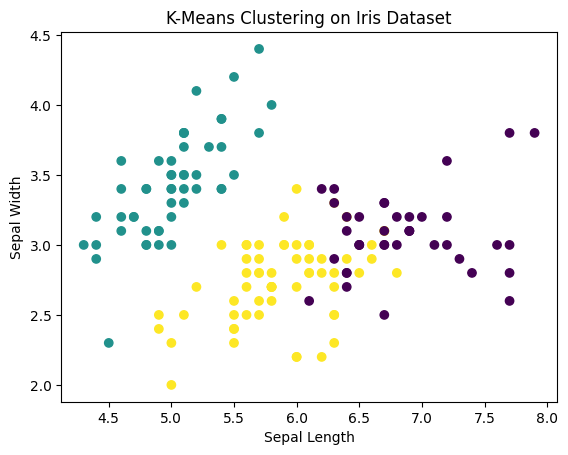

In [1]:
# Step 1: Import libraries
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 2: Load dataset from seaborn
iris = sns.load_dataset('iris')

# Step 3: Select features (drop species since it's the label)
X = iris.drop(columns=['species'])

# Step 4: Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Step 5: Add cluster labels to dataset
iris['cluster'] = kmeans.labels_

# Step 6: Visualize (using first two features)
plt.scatter(iris['sepal_length'], iris['sepal_width'], c=iris['cluster'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering on Iris Dataset')
plt.show()

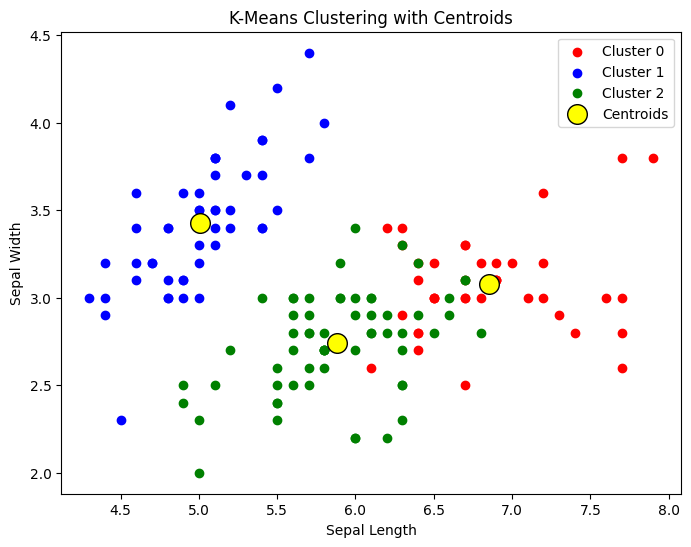

New data point [[5.1 3.5 1.4 0.2]] belongs to Cluster 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [6]:
# Step 1: Import libraries
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load dataset
iris = sns.load_dataset('iris')

# Step 3: Select features
X = iris.drop(columns=['species'])

# Step 4: Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Step 5: Add cluster labels
iris['cluster'] = kmeans.labels_

# Step 6: Plot clusters (using first two features)
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for i in range(3):
    cluster_data = iris[iris['cluster'] == i]
    plt.scatter(cluster_data['sepal_length'],
                cluster_data['sepal_width'],
                color=colors[i],
                label=f'Cluster {i}')

# Plot centroids (only first two features)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, c='yellow', marker='o', edgecolors='black',
            label='Centroids')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()

# Step 7: Take new input and predict cluster
# Format: [sepal_length, sepal_width, petal_length, petal_width]
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

predicted_cluster = kmeans.predict(new_sample)

print(f"New data point {new_sample} belongs to Cluster {predicted_cluster[0]}")

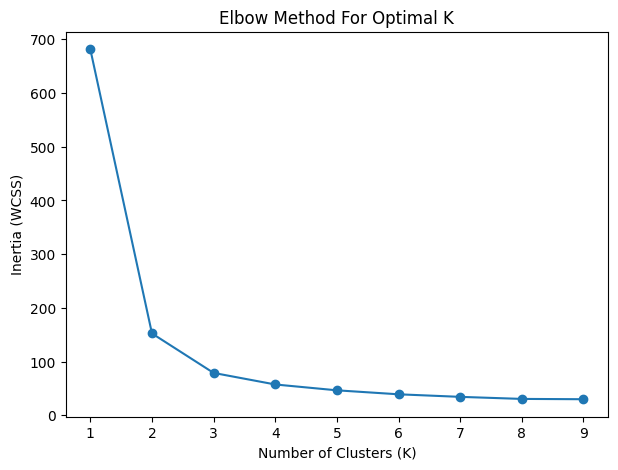

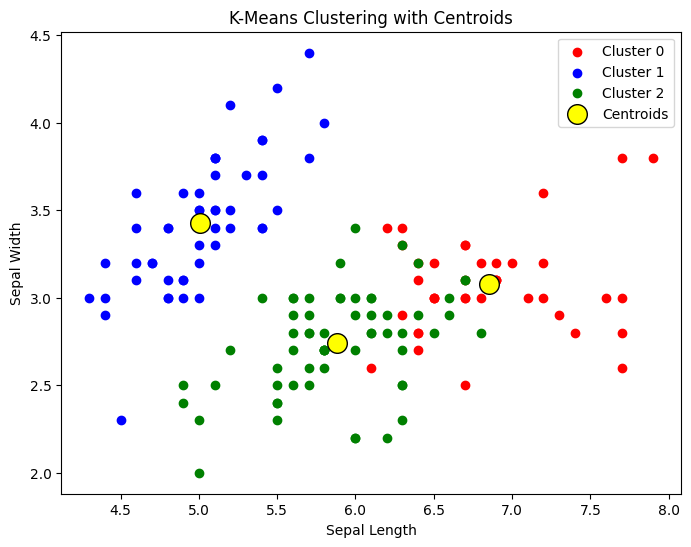

New data point [[5.1 3.5 1.4 0.2]] belongs to Cluster 1


c:\python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [2]:
# Step 1: Import libraries
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load dataset
iris = sns.load_dataset('iris')

# Step 3: Select features
X = iris.drop(columns=['species'])

# -------------------------------
# Step 4: Elbow Method
# -------------------------------
inertia = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal K')
plt.show()

# -------------------------------
# Step 5: Apply KMeans (choose K=3 based on elbow)
# -------------------------------
kmeans = KMeans(n_clusters=3, random_state=42 )
kmeans.fit(X)

# Step 6: Add cluster labels
iris['cluster'] = kmeans.labels_

# -------------------------------
# Step 7: Visualization
# -------------------------------
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for i in range(3):
    cluster_data = iris[iris['cluster'] == i]
    plt.scatter(cluster_data['sepal_length'],
                cluster_data['sepal_width'],
                color=colors[i],
                label=f'Cluster {i}')

# Centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, c='yellow', marker='o', edgecolors='black',
            label='Centroids')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()

# -------------------------------
# Step 8: Predict new sample
# -------------------------------
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

predicted_cluster = kmeans.predict(new_sample)

print(f"New data point {new_sample} belongs to Cluster {predicted_cluster[0]}")

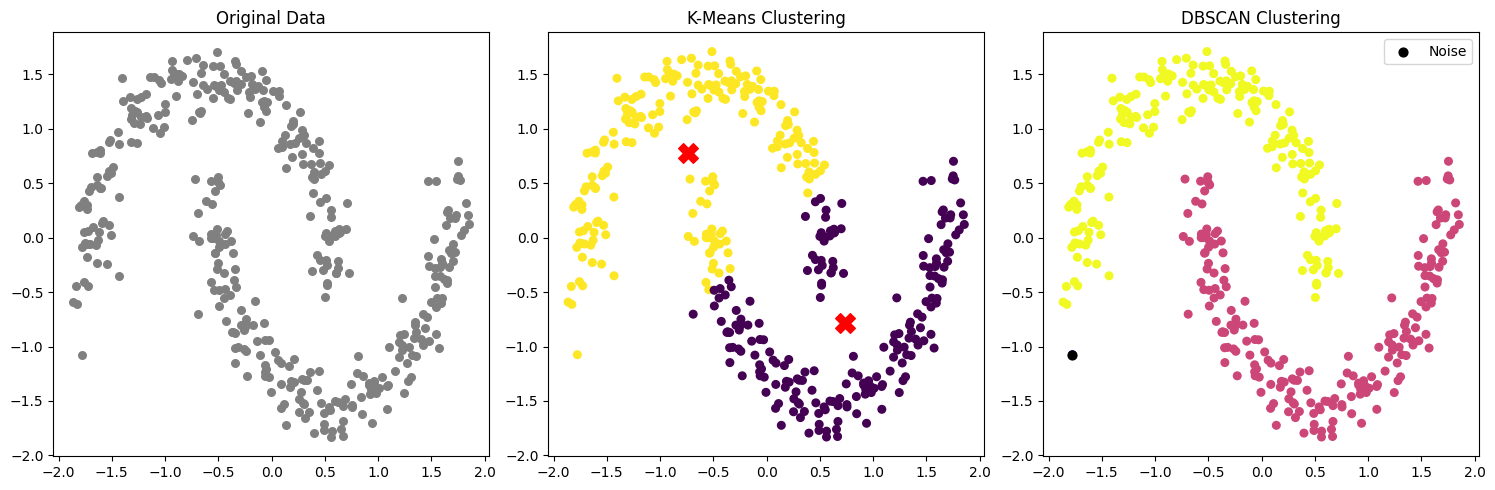

K-Means unique clusters: [0 1]
DBSCAN unique clusters: [-1  0  1]
DBSCAN noise points: 1


In [9]:
# ================================
# 1. Import Libraries
# ================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# ================================
# 2. Generate Dataset
# ================================
# Non-linear, curved clusters (perfect to show DBSCAN advantage)
X, y_true = make_moons(n_samples=400, noise=0.08, random_state=42)

# Scale data (important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 3. Apply K-Means
# ================================
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# ================================
# 4. Apply DBSCAN
# ================================
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# ================================
# 5. Visualization
# ================================
plt.figure(figsize=(15, 5))

# ---- Original Data ----
plt.subplot(1, 3, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', s=30)
plt.title("Original Data")

# ---- K-Means Result ----
plt.subplot(1, 3, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', s=30)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')
plt.title("K-Means Clustering")

# ---- DBSCAN Result ----
plt.subplot(1, 3, 3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='plasma', s=30)

# Highlight noise points (-1 label)
noise = dbscan_labels == -1
plt.scatter(X_scaled[noise, 0], X_scaled[noise, 1], c='black', s=40, label='Noise')
plt.title("DBSCAN Clustering")
plt.legend()

plt.tight_layout()
plt.show()

# ================================
# 6. Print Insights
# ================================
print("K-Means unique clusters:", np.unique(kmeans_labels))
print("DBSCAN unique clusters:", np.unique(dbscan_labels))
print("DBSCAN noise points:", np.sum(dbscan_labels == -1))

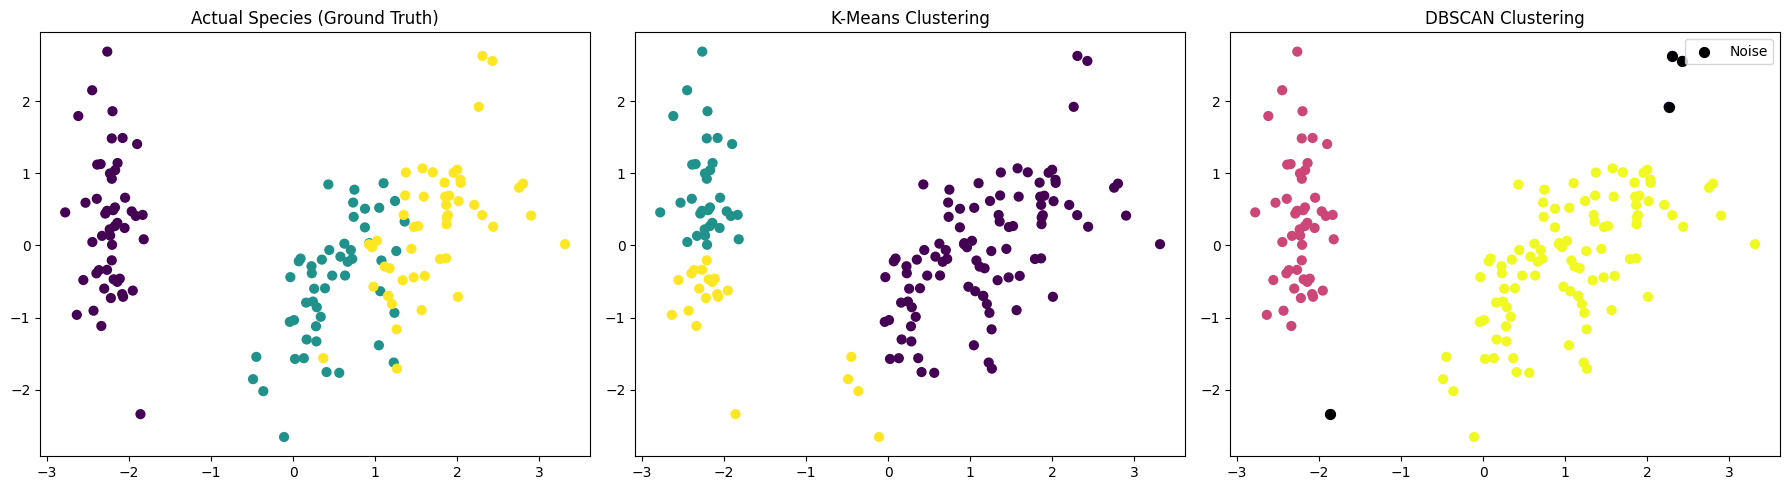

K-Means clusters: [0 1 2]
DBSCAN clusters: [-1  0  1]
DBSCAN noise points: 4


In [3]:
# ================================
# 1. Import Libraries
# ================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ================================
# 2. Load Real Dataset (Iris)
# ================================
iris = load_iris()
X = iris.data
y_true = iris.target  # actual labels (just for comparison)

# ================================
# 3. Scale the Data
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 4. Reduce to 2D (for visualization)
# ================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ================================
# 5. Apply K-Means
# ================================
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# ================================
# 6. Apply DBSCAN
# ================================
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# ================================
# 7. Plot Results
# ================================
plt.figure(figsize=(18, 5))

# ---- Ground Truth ----
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=40)
plt.title("Actual Species (Ground Truth)")

# ---- K-Means ----
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=40)
plt.title("K-Means Clustering")

# ---- DBSCAN ----
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='plasma', s=40)

# highlight noise
noise = dbscan_labels == -1
plt.scatter(X_pca[noise, 0], X_pca[noise, 1], c='black', s=50, label='Noise')

plt.title("DBSCAN Clustering")
plt.legend()

plt.tight_layout()
plt.show()

# ================================
# 8. Insights
# ================================
print("K-Means clusters:", np.unique(kmeans_labels))
print("DBSCAN clusters:", np.unique(dbscan_labels))
print("DBSCAN noise points:", np.sum(dbscan_labels == -1))

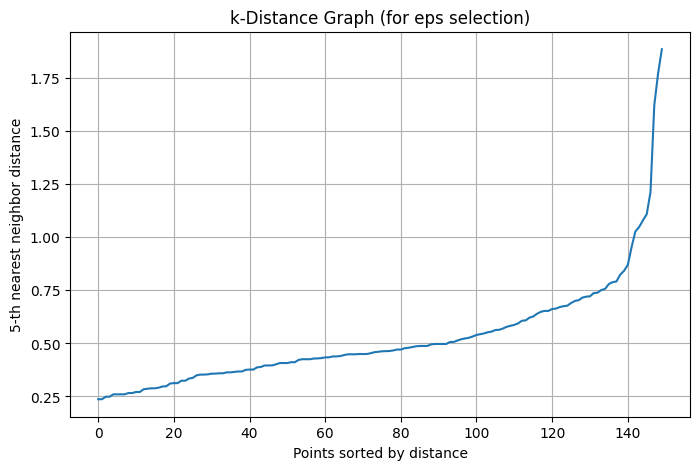

In [11]:
# ================================
# 1. Import Libraries
# ================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# ================================
# 2. Load & Scale Data
# ================================
X = load_iris().data
X = StandardScaler().fit_transform(X)

# ================================
# 3. Choose k (same as min_samples)
# ================================
k = 5  # rule of thumb: 2 * dimensions (or start with 4–5)

# ================================
# 4. Compute k-NN distances
# ================================
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

# Take distance to kth neighbor
k_distances = distances[:, k-1]

# Sort distances
k_distances = np.sort(k_distances)

# ================================
# 5. Plot k-distance graph
# ================================
plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title("k-Distance Graph (for eps selection)")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-th nearest neighbor distance")
plt.grid()
plt.show()

Explained variance: [0.33690046 0.26230645]


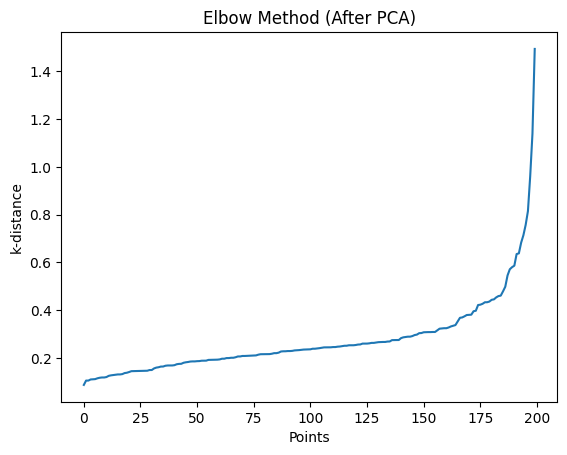

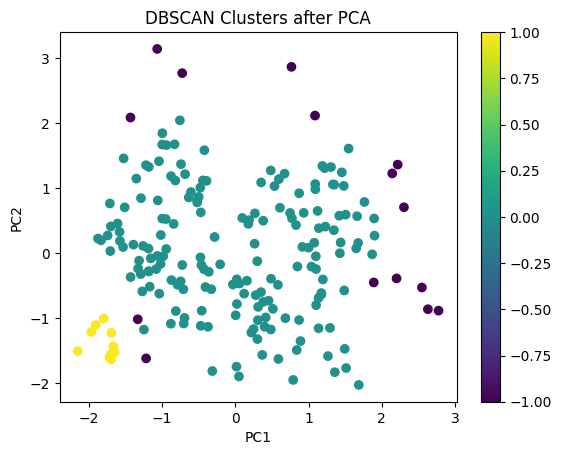

Clusters: 2
Noise points: 15


In [21]:
# 🔹 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# 🔹 2. Load dataset
df = pd.read_csv("Mall_Customers.csv")

# 🔹 3. Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# 🔹 4. Select features
X = df[['Age', 'Gender', 'Annual Income (k$)', 'Spending Score (1-100)']]

# 🔹 5. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 6. Apply PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

# 🔹 7. Find eps using k-distance
k = 4   # now dimensions = 2 → 2 * 2 = 4

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, k-1])

# 🔹 8. Plot k-distance graph
plt.figure()
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("k-distance")
plt.title("Elbow Method (After PCA)")
plt.show()

# 🔹 👉 Choose eps from graph
eps_value = 0.4

# 🔹 9. Apply DBSCAN on PCA data
dbscan = DBSCAN(eps=eps_value, min_samples=k)
labels = dbscan.fit_predict(X_pca)

df['Cluster'] = labels

# 🔹 10. Plot clusters (clean 2D!)
plt.figure()

# plot clusters
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
)

plt.title("DBSCAN Clusters after PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

# 🔹 11. Summary
print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", list(labels).count(-1))